12) Propose your own analysis and data presentation related to drugs. You may acquire additional information from other biomedical and bioinformatics databases available online. However, ensure that the selected database allows for automated data retrieval through a program.

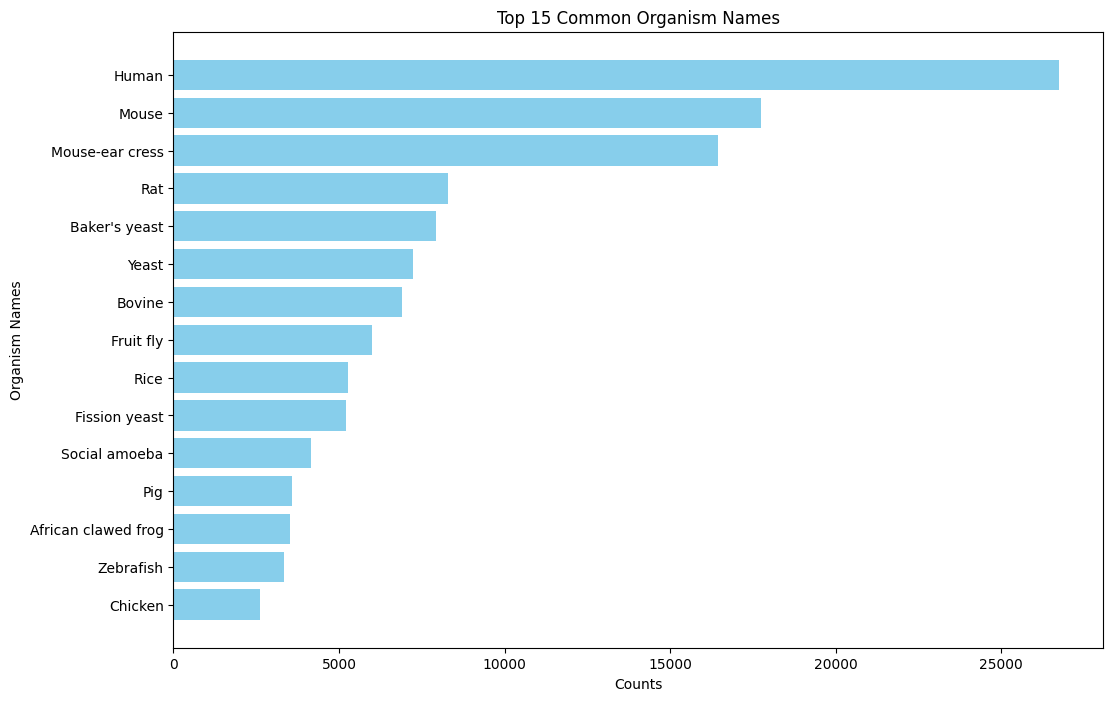

In [1]:
import xml.etree.ElementTree as ET
from collections import Counter
import matplotlib.pyplot as plt

# Define the file path to the XML data
file_path = "uniprot_sprot.xml"

# Initialize a counter to keep track of common names
common_name_counts = Counter()
context = ET.iterparse(file_path, events=("start", "end"))
context = iter(context)
_, root = next(context)

# Parse the XML file and count the occurrences of common names
for event, elem in context:
    if event == "end" and elem.tag.endswith("name") and elem.attrib.get("type") == "common":
        common_name_counts[elem.text] += 1
    root.clear()

# Extract the top 15 most common names and their counts
names, counts = zip(*common_name_counts.most_common(15))

# Plot a horizontal bar chart of the top 15 common organism names
plt.figure(figsize=(12, 8))
plt.barh(names, counts, color='skyblue')
plt.xlabel('Counts')
plt.ylabel('Organism Names')
plt.title('Top 15 Common Organism Names')
plt.gca().invert_yaxis()
plt.show()